# Chap 11 - Ex4: cluster customers in Online_Retail.csv

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn

np.set_printoptions(suppress = True)

In [2]:
retail = pd.read_csv('Data/Online_Retail.csv')
retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-10 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,09-12-11 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09-12-11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09-12-11 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09-12-11 12:50,4.15,12680.0,France


In [3]:
retail.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## <span style = 'color:yellow'> Feature Engineering: calculate new columns {Sales_avg, Sales_count}

In [4]:
retail = retail.dropna()
retail['Quantity'] = np.abs(retail.loc[:,'Quantity'])

retail['Sales'] = retail.loc[:,'Quantity']*retail.loc[:,'UnitPrice'] #Calculate Sales = Quantity*Unitprice
retail_groupby = retail.groupby(['CustomerID', 'InvoiceNo']).agg({'Sales':'sum'})
retail_groupby.reset_index(inplace=True)
retail_groupby

/tmp/ipykernel_1290372/2204883454.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  retail['Quantity'] = np.abs(retail.loc[:,'Quantity'])
/tmp/ipykernel_1290372/2204883454.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  retail['Sales'] = retail.loc[:,'Quantity']*retail.loc[:,'UnitPrice'] #Calculate Sales = Quantity*Unitprice


,CustomerID,InvoiceNo,Sales
0,12346.0,541431,77183.60
1,12346.0,C541433,77183.60
2,12347.0,537626,711.79
3,12347.0,542237,475.39
4,12347.0,549222,636.25
...,...,...,...
22185,18283.0,579673,223.61
22186,18283.0,580872,208.00
22187,18287.0,554065,765.28
22188,18287.0,570715,1001.32


In [5]:
retail_processed = retail_groupby.groupby('CustomerID').agg({'Sales':'mean', 'InvoiceNo':'count'})
retail_processed.reset_index(inplace = True)
retail_processed.columns = ['CustomerID', 'Sales_avg', 'Sales_count'] #Change columns' name
retail_processed

,CustomerID,Sales_avg,Sales_count
0,12346.0,77183.600000,2
1,12347.0,615.714286,7
2,12348.0,449.310000,4
3,12349.0,1757.550000,1
4,12350.0,334.400000,1
...,...,...,...
4367,18280.0,180.600000,1
4368,18281.0,80.820000,1
4369,18282.0,59.833333,3
4370,18283.0,130.930000,16


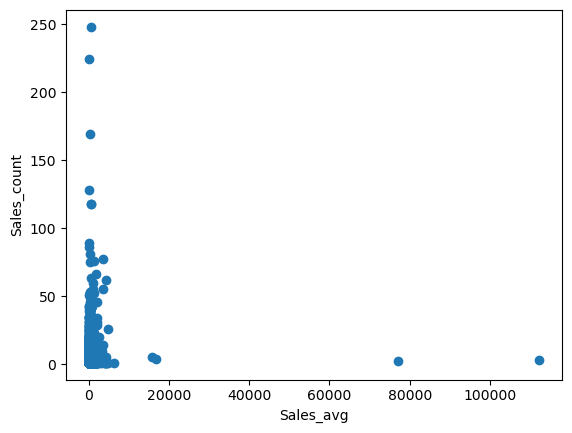

In [6]:
plt.scatter(retail_processed['Sales_avg'], retail_processed['Sales_count'])
plt.xlabel('Sales_avg')
plt.ylabel('Sales_count')
plt.show()

## <span style = 'color:yellow'> Check normal distribution and outliers of Sales_avg and Sales_count

Normality test of Sales_avg: ShapiroResult(statistic=0.04405423943971176, pvalue=3.1166328316963724e-91)
Normality test of Sales_count: ShapiroResult(statistic=0.37696582300089954, pvalue=1.1751929290219582e-81)



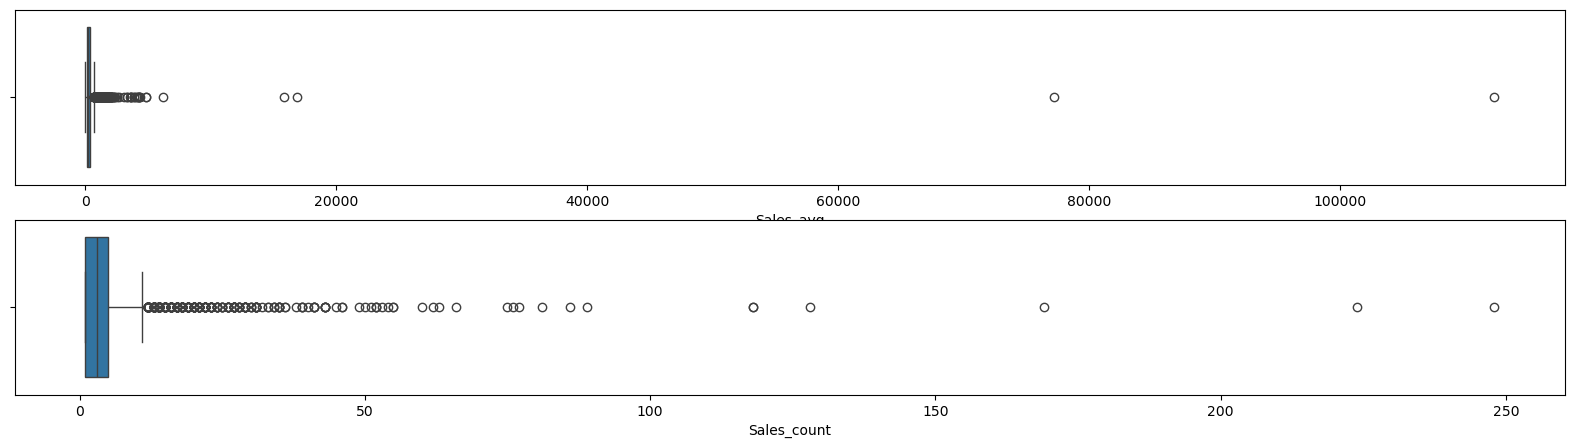


Sales_avg and Sales_count are not normally distributed, and also have outliers => Remove outliers 



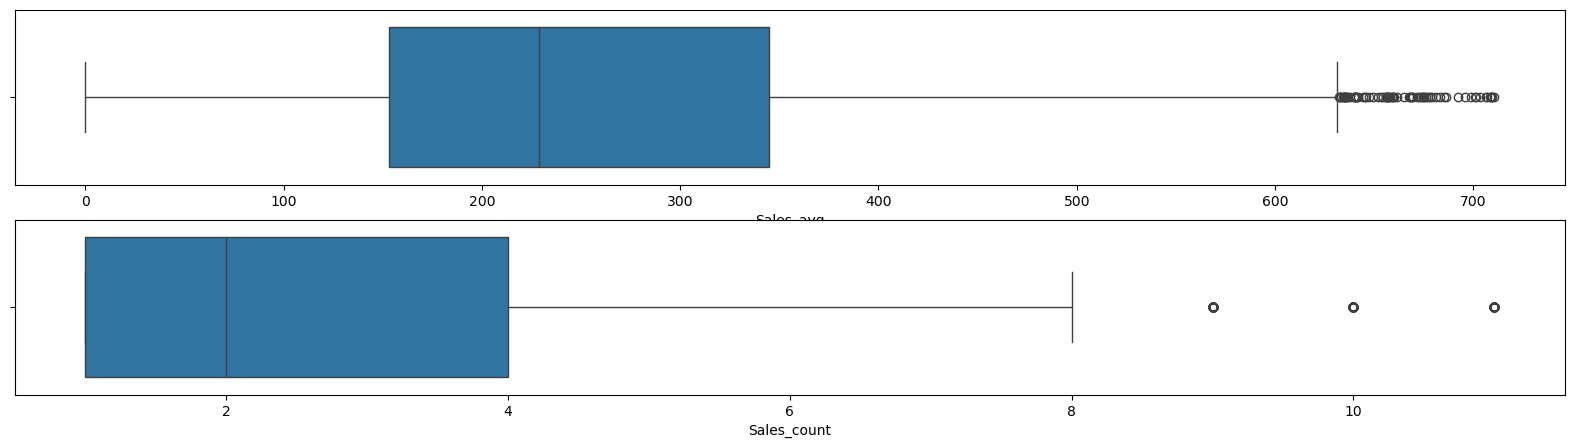

In [7]:
from scipy.stats import shapiro
print(f'Normality test of Sales_avg: {shapiro(retail_processed['Sales_avg'])}')
print(f'Normality test of Sales_count: {shapiro(retail_processed['Sales_count'])}')
print()

plt.figure(figsize = (20,5))
plt.subplot(2,1,1)
sbn.boxplot(data = retail_processed, x = 'Sales_avg')
plt.subplot(2,1,2)
sbn.boxplot(data = retail_processed, x = 'Sales_count')
plt.show()

print('\nSales_avg and Sales_count are not normally distributed, and also have outliers => Remove outliers \n')

def remove_outliers_rows(data, column_list):
    index_to_drop = []
    for col in column_list:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3-q1
        condition = (data[col] < (q1 - iqr*1.5)) | (data[col] > (q3 + iqr*1.5)) #Condition to get outliers
        index_to_drop += data.loc[condition, col].index.to_list() #Get the index of outliers from data[col] pandas series
    
    index_to_drop = list(set(index_to_drop)) #set to remove duplicate index values between variables
    data = data.drop(index_to_drop)
    return data.reset_index(drop=True)

retail_processed_no_out = remove_outliers_rows(retail_processed, ['Sales_avg', 'Sales_count'])

plt.figure(figsize = (20,5))
plt.subplot(2,1,1)
sbn.boxplot(data = retail_processed_no_out, x = 'Sales_avg')
plt.subplot(2,1,2)
sbn.boxplot(data = retail_processed_no_out, x = 'Sales_count')
plt.show()

## <span style = 'color:yellow'> Find optimal K using Elbow Method and Silhoutte Score

Silhouette score for k = 2: 0.02626518734730006
Silhouette score for k = 3: 0.22113188824309835
Silhouette score for k = 4: 0.3280174461108788
Silhouette score for k = 5: 0.14315528531542035
Silhouette score for k = 6: 0.06447288014632424
Silhouette score for k = 7: 0.01707776312543688
Silhouette score for k = 8: 0.058489162752229436
Silhouette score for k = 9: 0.004013224590078822


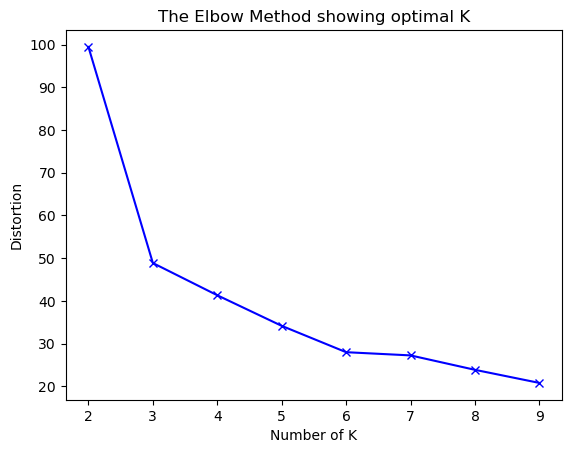


Choose K = 3


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.compose import make_column_transformer
import math

distortions = []
k_nums = range(2,10)

for k in k_nums:
    kmeans_pipe = Pipeline([
        ('RobustScaler', RobustScaler()),
        ('KMeansModel', KMeans(n_clusters = k, random_state = 1))
    ])
    inputs = retail_processed_no_out[['Sales_avg', 'Sales_count']]
    kmeans_pipe.fit(inputs)
    labels = kmeans_pipe.named_steps['KMeansModel'].labels_
    centroids = kmeans_pipe.named_steps['KMeansModel'].cluster_centers_
    centroids = kmeans_pipe.named_steps['RobustScaler'].inverse_transform(centroids) #Convert centroid coordinate back to original scale
    sum_var = sum(np.min(cdist(inputs, centroids, 'euclidean'), axis = 1)) / inputs.shape[0]
    distortions.append(sum_var)
    print(f'Silhouette score for k = {k}: {silhouette_score(inputs, labels)}')

plt.plot(k_nums, distortions, 'bx-')
plt.xlabel('Number of K')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing optimal K')
plt.show()

print('\nChoose K = 3')

## <span style = 'color:yellow'> Build official KMeansClustering with K = 3

In [9]:
kmeans_pipe = Pipeline([
    ('RobustScaler', RobustScaler()),
    ('KMeansModel', KMeans(n_clusters = 3, random_state = 1))
])
inputs = retail_processed_no_out[['Sales_avg', 'Sales_count']]
kmeans_pipe.fit(inputs)
labels = kmeans_pipe.named_steps['KMeansModel'].labels_
centroids = kmeans_pipe.named_steps['KMeansModel'].cluster_centers_
centroids = kmeans_pipe.named_steps['RobustScaler'].inverse_transform(centroids)

print('Coordinate of all centroids:\n', centroids)
print()

retail_processed_group = retail_processed_no_out.copy()
retail_processed_group['Group'] = labels
print(retail_processed_group)

Coordinate of all centroids:
 [[428.49927608   2.19230769]
 [164.52803705   2.09549072]
 [269.92375474   7.3130545 ]]

      CustomerID   Sales_avg  Sales_count  Group
0        12347.0  615.714286            7      2
1        12348.0  449.310000            4      0
2        12350.0  334.400000            1      0
3        12352.0  315.151818           11      2
4        12353.0   89.000000            1      1
...          ...         ...          ...    ...
3709     18278.0  173.900000            1      1
3710     18280.0  180.600000            1      1
3711     18281.0   80.820000            1      1
3712     18282.0   59.833333            3      1
3713     18287.0  612.426667            3      0

[3714 rows x 4 columns]


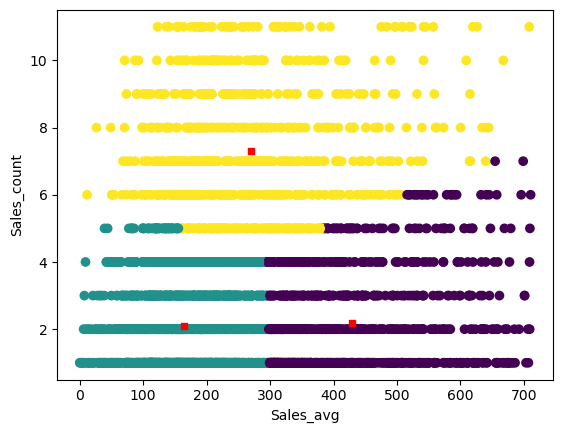

In [10]:
plt.scatter(retail_processed_no_out['Sales_avg'], retail_processed_no_out['Sales_count'], c = retail_processed_group['Group'])
plt.scatter(centroids[:,0], centroids[:,1], marker = 's', s = 25, color = 'red')
plt.xlabel('Sales_avg')
plt.ylabel('Sales_count')
plt.show()

# <span style = 'color:yellow'> Report clustering results

In [11]:
data_group = retail_processed_group.copy()
data_group.drop('CustomerID', axis = 1, inplace = True)

for group in data_group['Group'].unique():
    print(f'\n=============== Cluster group {group} =========================\n')
    data = data_group[data_group['Group'] == group]
    print(f'n_observations: {data.shape[0]}\n')
    for col_name in data.columns[:-1]:
        print(f'{col_name}: {np.min(data[col_name])} ~ {np.median(data[col_name])} ~ {np.max(data[col_name])}')
        print()


=============== Cluster group 2 =========================

n_observations: 791

Sales_avg: 11.67 ~ 250.152 ~ 708.3963636363636

Sales_count: 5 ~ 7.0 ~ 11


=============== Cluster group 0 =========================

n_observations: 1038

Sales_avg: 294.6325 ~ 402.5245 ~ 710.6066666666667

Sales_count: 1 ~ 2.0 ~ 7


=============== Cluster group 1 =========================

n_observations: 1885

Sales_avg: 0.0 ~ 162.57333333333332 ~ 298.11

Sales_count: 1 ~ 2.0 ~ 5



Number of numeric fields: 2

All numeric fields: ['Sales_avg', 'Sales_count']



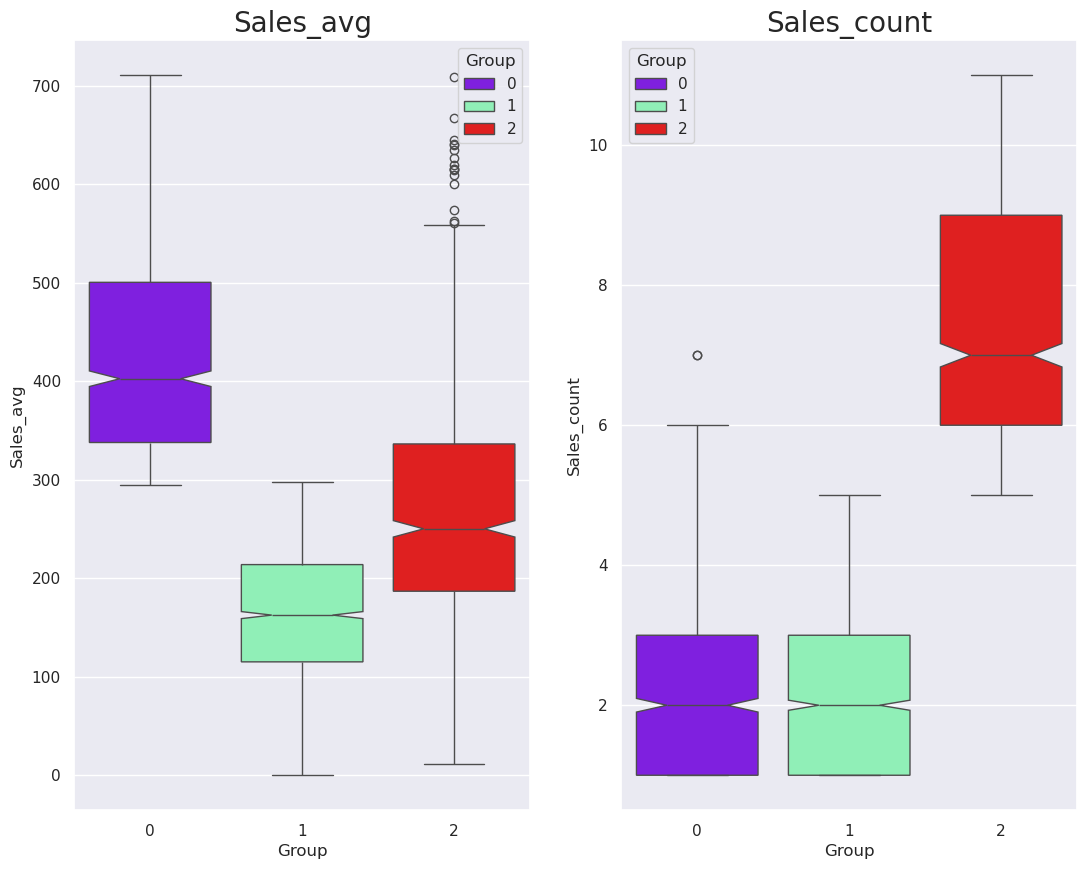

In [12]:
# Method 3
data_group = retail_processed_group.copy()

numeric_cols = ['Sales_avg', 'Sales_count']

##### Function building ##############

def boxplot_numeric(df, numeric_cols, figsize=(20, 10), groups = None):
    col = 3
    if (len(numeric_cols) % 3) == 0:
        row = len(numeric_cols) // 3
    else:
        row = (len(numeric_cols) // 3) + 1
    '''
    numeric_cols: list các tên cột biến định lượng
    row: số lượng dòng trong lưới đồ thị
    col: số lượng cột trong lưới đồ thị
    figsize: kích thước biểu đồ
    groups: tên cột chứa biến phân nhóm như 'Group' hoặc 'Class' hoặc 'Label'
    '''
    print(f'Number of numeric fields: {len(numeric_cols)}')
    print()
    print(f'All numeric fields: {numeric_cols}')
    print()
    plt.figure(figsize = figsize)
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2, hspace=0.3)
    for i in range(1, len(numeric_cols)+1, 1):
      try:
        plt.subplot(row, col, i)
        sbn.boxplot(data = df, x = groups, y = numeric_cols[i-1], notch = True, hue = groups, palette = 'rainbow')
        plt.title(numeric_cols[i-1], size = 20)
      except:
        print('Error {}'.format(numeric_cols[i-1]))
        break
    plt.show()

## Draw
sbn.set_theme(style ='darkgrid')
boxplot_numeric(data_group, numeric_cols, groups = data_group.iloc[:,-1])